In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("dataset/train.csv")

In [3]:
colmns = data.columns.to_list()
colmns.remove('label')

In [4]:
train_data = data[colmns].to_numpy()
train_data = train_data/255 # normalizing the data as pixel range is between 0-255

In [5]:
train_label = data['label'].to_numpy()

In [6]:
# one hot encoding train label
y_train = []
for value in train_label:
    row = np.zeros((10))
    row[value]=1
    y_train.append(row)

In [7]:
np.random.seed(150)
def hidden_layer(input_dim, output_dim):
    if output_dim != None:
        return np.random.rand(input_dim,output_dim)
    else:
        return np.random.rand(input_dim,)

class ModelNotReady(Exception):
        """Error raised when model isnt built"""
        pass
class InvalidInputSize(Exception):
    """Error raised when input size is incomplete"""
    pass
class model:

    def __init__(self,num_layers,input_size,output_size,hidden_layer_size=[]):
        self.num_layers = num_layers
        self.input_size = input_size
        self.model = []
        self.hidden_layer_size = hidden_layer_size
        self.output_size = output_size
        self.bias = []
        self.layers = []
        self.model = []
        # storing the inputs and z values at each layer.
        self.inputs = []
        self.z_values = []


    def make(self):
        # hidden layer size tells the size of the neuron for each layer order wise
        if len(self.hidden_layer_size) != self.num_layers:
            print("error making the model")
            return None
        for i in range(self.num_layers):
            # creating the input layer
            if i ==0:
                self.layers.append(hidden_layer(self.input_size,self.hidden_layer_size[i]))
                self.bias.append(hidden_layer(self.hidden_layer_size[i],None))

            # deciding the shape for layers in between (current_hidden_layer_size,next_hidden_layer_size)
            if i+1 < self.num_layers:
                matrix_shape = (self.hidden_layer_size[i],self.hidden_layer_size[i+1])
                bias_shape = self.hidden_layer_size[i+1]

            # if this is the last layer then the shape of the matrix is (hidden_layer_size,output_size)
            else:
                matrix_shape = (self.hidden_layer_size[i],self.output_size)
                bias_shape = self.output_size
            
            # storing the layer matrix
            self.layers.append(hidden_layer(*matrix_shape))
            # storing the bias matrix
            if bias_shape != None:
                bias_layer = hidden_layer(bias_shape,None)
                self.bias.append(bias_layer)
            
        for layer,bias in zip(self.layers,self.bias):
            # creating the model
            self.model.append((layer,bias))
        # returning the model
        return self.model
    
    def activation(self,matrix,function="relu"):
        if function ==  "relu":
            return np.maximum(0,matrix)
        

    def forward_pass(self,input):

        # making sure that model is made
        self.x = input
        if self.model == []:
            raise ModelNotReady("Please make the model first.")
        # passed input's size should match the model's input size 
        if not input.shape[1] == self.input_size:
            raise InvalidInputSize("the size of the input doesnt math the model's input architecture.")
        
        # forward propagation
        for layer_num,layer in enumerate(self.model):
            # Z = X.W+B
            self.x = np.dot(self.x,layer[0]) +layer[1]
            # applying the activation function to all the layers except the last layer
            # because the output should contain the max range for the in case of regression.
            if not layer_num +1 == len(self.model) :
                self.x = self.activation(self.x)

        # returning the output.
        return self.x
    
    def compute_loss(self,y_pred,y_true):
        # squared error
        matrix_squared_error = np.array((y_true-y_pred)**2)
        return matrix_squared_error.mean()

# Creating a sample neural network below
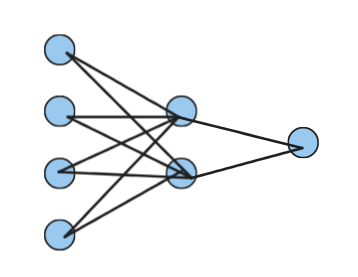

In [8]:
# input layer has 4 inputs and first hidden layer has 2 neurons and output is one
np.random.seed(150)

model_from_scratch = model(1,4,1,[2])
m=model_from_scratch.make()
num_samples = 15
input_size = model_from_scratch.input_size
input = np.random.rand(num_samples,input_size)

In [9]:
model_from_scratch.forward_pass(input)

array([[1.66343958],
       [1.62596701],
       [1.2996595 ],
       [1.3435729 ],
       [1.36859918],
       [1.50158299],
       [1.79632793],
       [1.85071847],
       [1.11587701],
       [2.01717565],
       [1.48864363],
       [1.43125292],
       [1.38691648],
       [1.26647336],
       [1.16618657]])

In [10]:
m = model(5,784,10,[128,128,64,64,32])
m.make()

[(array([[0.18163476, 0.97270255, 0.2130712 , ..., 0.7164983 , 0.62291396,
          0.03592296],
         [0.88434543, 0.18721176, 0.55575909, ..., 0.12122777, 0.74588148,
          0.59734032],
         [0.19552317, 0.42219807, 0.1670445 , ..., 0.45647095, 0.17177994,
          0.80139416],
         ...,
         [0.24934574, 0.26051311, 0.29867098, ..., 0.45163753, 0.86940472,
          0.56062008],
         [0.33243497, 0.81820244, 0.96730613, ..., 0.95038154, 0.62366414,
          0.18158547],
         [0.11392701, 0.10378185, 0.43486923, ..., 0.71491648, 0.95450478,
          0.04713116]], shape=(784, 128)),
  array([2.90296872e-01, 6.12055628e-01, 5.15504767e-01, 6.15167721e-01,
         4.66180295e-01, 2.27437544e-01, 7.07437977e-01, 6.16952818e-01,
         8.59457004e-01, 4.24512111e-02, 2.01342756e-01, 1.97449136e-01,
         3.57915691e-02, 5.69075073e-01, 2.85992088e-01, 2.55582200e-01,
         8.77395571e-01, 8.27470347e-01, 8.43723487e-04, 4.64930960e-01,
         1.35

In [11]:
m.forward_pass(train_data)

array([[1.99717536e+09, 1.84080074e+09, 2.04138859e+09, ...,
        2.10789485e+09, 1.95500947e+09, 2.02703640e+09],
       [5.33818306e+09, 4.92021505e+09, 5.45635942e+09, ...,
        5.63412137e+09, 5.22548071e+09, 5.41799840e+09],
       [1.62596708e+09, 1.49865743e+09, 1.66196254e+09, ...,
        1.71610764e+09, 1.59163885e+09, 1.65027843e+09],
       ...,
       [3.74954530e+09, 3.45596421e+09, 3.83255272e+09, ...,
        3.95741305e+09, 3.67038322e+09, 3.80560802e+09],
       [3.17245487e+09, 2.92405847e+09, 3.24268653e+09, ...,
        3.34832964e+09, 3.10547640e+09, 3.21988896e+09],
       [2.18303636e+09, 2.01210991e+09, 2.23136440e+09, ...,
        2.30405989e+09, 2.13694749e+09, 2.21567729e+09]],
      shape=(42000, 10))

In [12]:
m.compute_loss(m.forward_pass(train_data),y_train)

np.float64(1.1374692280213985e+19)